# Regresion Clasica - Real Estate Price Prediction (Florida)

Entrena y compara modelos de regresion clasica (sin tree-based) con FE aplicado.
Se excluyen features con riesgo de leakage (`taxAssessedValue`, `last_listing_price`, etc.).

**Modelos evaluados:** Ridge, Lasso, ElasticNet, HuberRegressor, BayesianRidge, SVR(rbf)

**Flujo:**
1. Imports & Config
2. Carga de datos
3. Preprocesamiento (encoding, scaling, imputacion)
4. Comparacion de modelos por MAPE (5-Fold CV)
5. Entrenamiento KFold final + OOF para metamodelo (mejor modelo del CV)
6. Evaluacion OOF
7. Exportacion: OOF train, pred test, submission competition

---
## 1. Imports & Config

In [2]:
from __future__ import annotations
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor, BayesianRidge
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.base import clone

warnings.filterwarnings('ignore')

ROOT        = Path('../..')
DATA_DIR    = ROOT / 'data' / 'tabular'
SUBMISSIONS = ROOT / 'submissions'

TRAIN_PATH     = DATA_DIR / 'train_fe.parquet'
TEST_PATH      = DATA_DIR / 'test_fe.parquet'
COMP_TEST_PATH = DATA_DIR / 'competition_test_fe.parquet'

ID_COL     = 'zpid'
TARGET     = 'log_price'
TARGET_RAW = 'lastSoldPrice_hpi_adjusted'
STRAT_COL  = 'price_bin'

# Leakage: correlacion muy alta con el precio o derivadas del precio
LEAKAGE_COLS   = {'taxAssessedValue', 'last_listing_price',
                  'latest_tax_value', 'latest_tax_paid', 'propertyTaxRate'}
ALWAYS_EXCLUDE = {ID_COL, TARGET, TARGET_RAW, STRAT_COL, 'description'}

SEED            = 42
N_FOLDS         = 5
SUBMISSION_NAME = 'Pippin_02.00'

np.random.seed(SEED)
print('Config OK')

Config OK


---
## 2. Carga de Datos

In [3]:
df_train     = pd.read_parquet(TRAIN_PATH)
df_test      = pd.read_parquet(TEST_PATH)
df_comp_test = pd.read_parquet(COMP_TEST_PATH)

print(f'Train      : {df_train.shape}')
print(f'Test       : {df_test.shape}')
print(f'Comp. Test : {df_comp_test.shape}')
print()
print('Target (log_price) stats:')
print(df_train[TARGET].describe().round(4))

Train      : (9472, 140)
Test       : (2368, 140)
Comp. Test : (5038, 137)

Target (log_price) stats:
count    9472.0000
mean       13.0327
std         0.6629
min        10.8478
25%        12.6247
50%        13.0654
75%        13.4990
max        14.5021
Name: log_price, dtype: float64


---
## 3. Preprocesamiento

Los modelos lineales/SVR requieren:
- **Imputacion** de nulos (mediana para numericas, constante para categoricas)
- **Encoding** ordinal para categoricas (`homeType`, `zipcode`, `zip_3digit`)
- **Scaling** estandar para todas las features

El `ColumnTransformer` se ajusta SOLO sobre train y se aplica sobre test y competition_test.

In [4]:
EXCLUDE_ALL  = ALWAYS_EXCLUDE | LEAKAGE_COLS
available    = [c for c in df_train.columns if c not in EXCLUDE_ALL]

CAT_COLS = [c for c in available
            if str(df_train[c].dtype) in ('object', 'category')]
NUM_COLS     = [c for c in available if c not in CAT_COLS]
FEATURE_COLS = NUM_COLS + CAT_COLS

print(f'Features totales : {len(FEATURE_COLS)}')
print(f'  Numericas      : {len(NUM_COLS)}')
print(f'  Categoricas    : {len(CAT_COLS)} -> {CAT_COLS}')
leakage_found = sorted(LEAKAGE_COLS.intersection(set(df_train.columns)))
print(f'Leakage excluido : {leakage_found}')

Features totales : 130
  Numericas      : 129
  Categoricas    : 1 -> ['homeType']
Leakage excluido : ['last_listing_price', 'latest_tax_paid', 'latest_tax_value', 'propertyTaxRate', 'taxAssessedValue']


In [5]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ('scaler',  StandardScaler()),
])
preprocessor = ColumnTransformer(
    [('num', num_pipe, NUM_COLS), ('cat', cat_pipe, CAT_COLS)],
    remainder='drop',
)

X_train_raw = df_train[FEATURE_COLS].copy()
y_train     = df_train[TARGET].values
strat       = df_train[STRAT_COL].astype(str)

X_test_raw = df_test[FEATURE_COLS].copy()
y_test_raw = df_test[TARGET_RAW].values if TARGET_RAW in df_test.columns else None
X_comp_raw = df_comp_test[FEATURE_COLS].copy()

# Ajusta SOLO sobre train
X_train = preprocessor.fit_transform(X_train_raw)
X_test  = preprocessor.transform(X_test_raw)
X_comp  = preprocessor.transform(X_comp_raw)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'X_comp  : {X_comp.shape}')
print(f'NaNs en X_train: {np.isnan(X_train).sum()}')

X_train : (9472, 130)
X_test  : (2368, 130)
X_comp  : (5038, 130)
NaNs en X_train: 0


---
## 4. Comparacion de Modelos por MAPE (5-Fold CV)

Evaluacion con parametros por defecto para identificar los mejores candidatos a tunear.

In [ ]:
def mape_cv(model, X, y_log, strat_labels, n_folds=5, seed=42):
    """MAPE promedio en CV estratificado. Convierte a escala real antes de medir."""
    skf    = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    mapes  = []
    y_real = np.expm1(y_log)
    for tr_idx, val_idx in skf.split(X, strat_labels):
        model.fit(X[tr_idx], y_log[tr_idx])
        preds = np.expm1(model.predict(X[val_idx]))
        mapes.append(mean_absolute_percentage_error(y_real[val_idx], preds))
    return float(np.mean(mapes)), float(np.std(mapes))


candidates = {
    'Ridge'         : Ridge(alpha=1.0),
    'Lasso'         : Lasso(alpha=0.001, max_iter=10000),
    'ElasticNet'    : ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000),
    'HuberRegressor': HuberRegressor(max_iter=500),
    'BayesianRidge' : BayesianRidge(),
    'SVR_rbf'       : SVR(kernel='rbf', C=10, epsilon=0.01),
}

results = {}
print(f'{"Modelo":<18} {"MAPE mean":>12} {"MAPE std":>10}')
print('-' * 44)
for name, model in candidates.items():
    mu, sd = mape_cv(model, X_train, y_train, strat)
    results[name] = {'mean': mu, 'std': sd}
    print(f'{name:<18} {mu*100:>10.2f}%  {sd*100:>8.2f}%')

best_name = min(results, key=lambda k: results[k]['mean'])
print(f'\nMejor modelo baseline: {best_name}  MAPE={results[best_name]["mean"]*100:.2f}%')

Modelo                MAPE mean   MAPE std
--------------------------------------------
Ridge                   31.27%      0.65%
Lasso                   31.29%      0.79%
ElasticNet              31.24%      0.72%
HuberRegressor          31.79%      0.48%
BayesianRidge           31.30%      0.66%


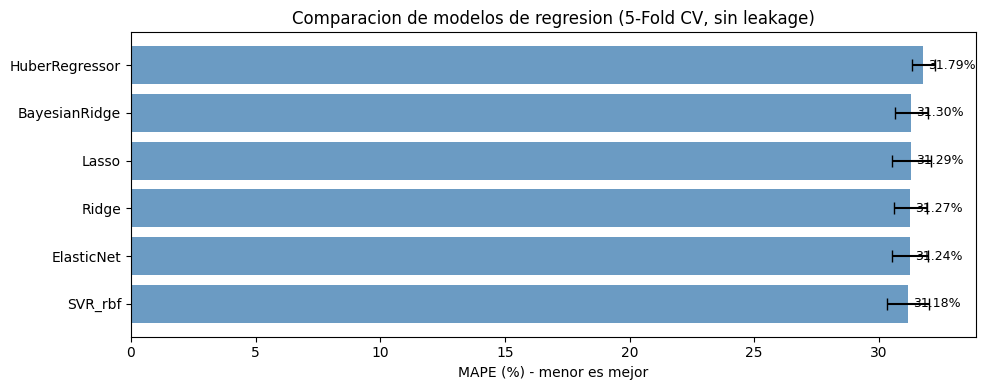

In [ ]:
res_df = pd.DataFrame(results).T.sort_values('mean')

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(res_df.index, res_df['mean'] * 100,
               xerr=res_df['std'] * 100, capsize=4,
               color='steelblue', alpha=0.8)
ax.set_xlabel('MAPE (%) - menor es mejor')
ax.set_title('Comparacion de modelos de regresion (5-Fold CV, sin leakage)')
for bar, (_, row) in zip(bars, res_df.iterrows()):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{row["mean"]*100:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. Entrenamiento KFold Final + OOF para Metamodelo

Las predicciones OOF sobre train se usan como features del metamodelo de stacking.
Las predicciones de test y competition_test se promedian sobre los N_FOLDS modelos.
Se usa el modelo con menor MAPE del CV de la seccion anterior.

In [ ]:
winner_name  = best_name
winner_model = candidates[winner_name]

skf_final = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_log  = np.zeros(len(X_train))
test_log = np.zeros(len(X_test))
comp_log = np.zeros(len(X_comp))
fold_mapes = []

print(f'Modelo: {winner_name}  |  KFold={N_FOLDS}\n')

for fold, (tr_idx, val_idx) in enumerate(skf_final.split(X_train, strat)):
    m = clone(winner_model)
    m.fit(X_train[tr_idx], y_train[tr_idx])

    oof_log[val_idx] = m.predict(X_train[val_idx])
    test_log        += m.predict(X_test) / N_FOLDS
    comp_log        += m.predict(X_comp) / N_FOLDS

    fm = mean_absolute_percentage_error(
        np.expm1(y_train[val_idx]), np.expm1(oof_log[val_idx]))
    fold_mapes.append(fm)
    print(f'  Fold {fold+1}/{N_FOLDS} | MAPE={fm:.4f} ({fm*100:.2f}%)')

print(f'\nMAPE OOF mean : {np.mean(fold_mapes):.4f} ({np.mean(fold_mapes)*100:.2f}%)')
print(f'MAPE OOF std  : {np.std(fold_mapes):.4f}')

Modelo: SVR_rbf  |  KFold=5

  Fold 1/5 | MAPE=0.3229 (32.29%)
  Fold 2/5 | MAPE=0.3068 (30.68%)
  Fold 3/5 | MAPE=0.3182 (31.82%)
  Fold 4/5 | MAPE=0.2990 (29.90%)
  Fold 5/5 | MAPE=0.3123 (31.23%)

MAPE OOF mean : 0.3118 (31.18%)
MAPE OOF std  : 0.0084


---
## 6. Evaluacion OOF

In [ ]:
oof_price = np.expm1(oof_log)
y_tr_raw  = np.expm1(y_train)

oof_mape     = mean_absolute_percentage_error(y_tr_raw, oof_price)
oof_rmse_log = np.sqrt(np.mean((oof_log - y_train) ** 2))
oof_mae      = np.mean(np.abs(y_tr_raw - oof_price))

print('=== Metricas OOF ===')
print(f'  MAPE      : {oof_mape:.4f}  ({oof_mape*100:.2f}%)')
print(f'  RMSE(log) : {oof_rmse_log:.4f}')
print(f'  MAE       : ${oof_mae:,.0f} USD')

oof_df = pd.DataFrame({'real': y_tr_raw, 'pred': oof_price,
                        'price_bin': df_train[STRAT_COL].values})
oof_df['ape'] = (oof_df['real'] - oof_df['pred']).abs() / oof_df['real']
print('\nMAPE por bin de precio:')
print(oof_df.groupby('price_bin')['ape'].mean().sort_index()
      .apply(lambda x: f'{x*100:.2f}%').to_string())

=== Metricas OOF ===
  MAPE      : 0.3118  (31.18%)
  RMSE(log) : 0.3811
  MAE       : $140,890 USD

MAPE por bin de precio:
price_bin
Q1     91.03%
Q2     36.21%
Q3     29.82%
Q4     22.53%
Q5     21.33%
Q6     20.18%
Q7     19.88%
Q8     21.29%
Q9     22.91%
Q10    26.67%


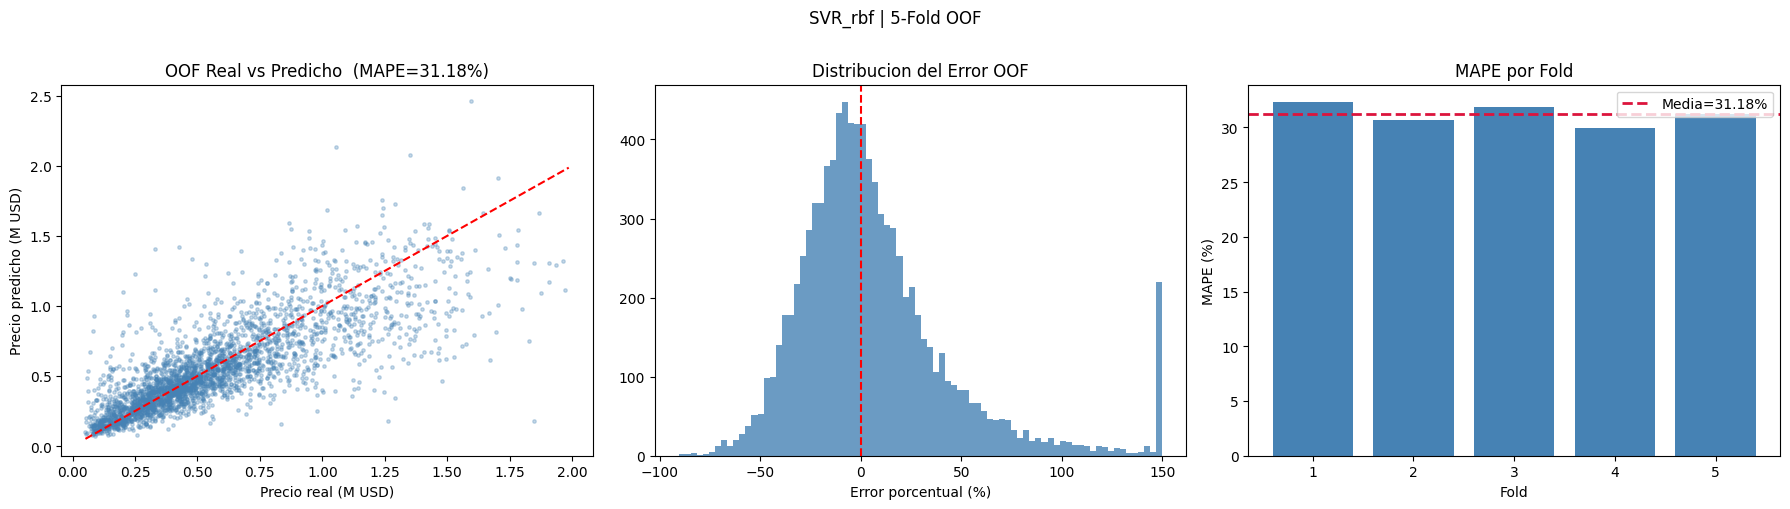

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rng    = np.random.default_rng(SEED)
sample = rng.choice(len(y_tr_raw), size=min(3000, len(y_tr_raw)), replace=False)
mn, mx = y_tr_raw.min() / 1e6, y_tr_raw.max() / 1e6

axes[0].scatter(y_tr_raw[sample] / 1e6, oof_price[sample] / 1e6,
                alpha=0.3, s=6, color='steelblue')
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5)
axes[0].set_xlabel('Precio real (M USD)')
axes[0].set_ylabel('Precio predicho (M USD)')
axes[0].set_title(f'OOF Real vs Predicho  (MAPE={oof_mape*100:.2f}%)')

pct_err = (oof_price - y_tr_raw) / y_tr_raw * 100
axes[1].hist(pct_err.clip(-150, 150), bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('Error porcentual (%)')
axes[1].set_title('Distribucion del Error OOF')

axes[2].bar(range(1, N_FOLDS + 1), [m * 100 for m in fold_mapes], color='steelblue')
axes[2].axhline(np.mean(fold_mapes) * 100, color='crimson', lw=2, linestyle='--',
                label=f'Media={np.mean(fold_mapes)*100:.2f}%')
axes[2].set_xlabel('Fold')
axes[2].set_ylabel('MAPE (%)')
axes[2].set_title('MAPE por Fold')
axes[2].legend()

plt.suptitle(f'{winner_name} | {N_FOLDS}-Fold OOF', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Exportacion de Predicciones

- `data/meta/oof_regression.csv` — OOF de train para el metamodelo de stacking
- `data/meta/test_regression.csv` — predicciones sobre test holdout para el metamodelo
- `data/meta/comp_regression.csv` — predicciones sobre competition_test para el metamodelo
- `submissions/{SUBMISSION_NAME}.csv` — submission individual de la competencia

In [ ]:
META_DIR = ROOT / 'data' / 'meta'
META_DIR.mkdir(parents=True, exist_ok=True)

# 1. OOF de train (para metamodelo)
pd.DataFrame({
    'zpid'                : df_train[ID_COL].values,
    'regression_oof_log'  : oof_log,
    'regression_oof_price': oof_price.round(2),
}).to_csv(META_DIR / 'oof_regression.csv', index=False)
print(f'OOF train  : {META_DIR / "oof_regression.csv"}')

# 2. Predicciones test holdout (para metamodelo)
test_price = np.expm1(test_log)
pd.DataFrame({
    'zpid'                 : df_test[ID_COL].values,
    'regression_pred_log'  : test_log,
    'regression_pred_price': test_price.round(2),
}).to_csv(META_DIR / 'test_regression.csv', index=False)
print(f'Test pred  : {META_DIR / "test_regression.csv"}')

if y_test_raw is not None:
    test_mape = mean_absolute_percentage_error(y_test_raw, test_price)
    print(f'MAPE en test holdout: {test_mape*100:.2f}%')

# 3. Predicciones competition_test (para metamodelo — input, no submission)
comp_price = np.expm1(comp_log)
pd.DataFrame({
    'zpid'                 : df_comp_test[ID_COL].values,
    'regression_pred_log'  : comp_log,
    'regression_pred_price': comp_price.round(2),
}).to_csv(META_DIR / 'comp_regression.csv', index=False)
print(f'Comp pred  : {META_DIR / "comp_regression.csv"}')

# 4. Competition submission (formato requerido por la competencia)
submission = pd.DataFrame({
    'zpid'           : df_comp_test[ID_COL].values,
    'predicted_price': comp_price.round(2),
})
sub_path = SUBMISSIONS / f'{SUBMISSION_NAME}.csv'
submission.to_csv(sub_path, index=False)
print(f'Submission : {sub_path}')

check = pd.read_csv(sub_path)
assert list(check.columns) == ['zpid', 'predicted_price']
assert check['predicted_price'].notna().all()
assert (check['predicted_price'] > 0).all()

print()
print('=== Resumen Final ===')
print(f'  Modelo           : {winner_name}')
print(f'  MAPE OOF (train) : {oof_mape*100:.2f}%')
if y_test_raw is not None:
    print(f'  MAPE test holdout: {test_mape*100:.2f}%')
print(f'  Precio mediano   : ${check["predicted_price"].median():,.0f}')
print(f'  Precio minimo    : ${check["predicted_price"].min():,.0f}')
print(f'  Precio maximo    : ${check["predicted_price"].max():,.0f}')
print()
print(check.head(10).to_string(index=False))
print('\nSubmission OK')

OOF train  : ..\..\data\meta\oof_regression.csv
Test pred  : ..\..\data\meta\test_regression.csv
MAPE en test holdout: 29.43%
Comp pred  : ..\..\data\meta\comp_regression.csv
Submission : ..\..\submissions\Pippin_02.00.csv

=== Resumen Final ===
  Modelo           : SVR_rbf
  MAPE OOF (train) : 31.18%
  MAPE test holdout: 29.43%
  Precio mediano   : $479,270
  Precio minimo    : $64,570
  Precio maximo    : $2,516,116

   zpid  predicted_price
1009018        408555.06
1001436        599009.21
1010988        571967.53
1002184        289037.45
1015717        272741.01
1001346        706590.95
1006728        152158.31
1002644        308848.45
1009198        839947.19
1008339        582426.08

Submission OK


---
## 7.1. Exportacion Train — submissions/test/

Combina las predicciones OOF del train (9 472 filas) con las predicciones del holdout (2 368 filas)
y las guarda en `submissions/test/<SUBMISSION_NAME>.csv` con el mismo formato que la submission oficial.

In [ ]:
TEST_SUBMISSIONS = SUBMISSIONS / 'test'
TEST_SUBMISSIONS.mkdir(parents=True, exist_ok=True)

train_export = pd.DataFrame({
    'zpid'            : df_train[ID_COL].values,
    'predicted_price' : oof_price.round(2),
})

holdout_export = pd.DataFrame({
    'zpid'            : df_test[ID_COL].values,
    'predicted_price' : test_price.round(2),
})

train_full_export = pd.concat([train_export, holdout_export], ignore_index=True)

train_out_path = TEST_SUBMISSIONS / f'{SUBMISSION_NAME}.csv'
train_full_export.to_csv(train_out_path, index=False)

check_train = pd.read_csv(train_out_path)
assert list(check_train.columns) == ['zpid', 'predicted_price'], 'Columnas incorrectas'
assert check_train['predicted_price'].notna().all(), 'Hay NaN en predicciones'
assert (check_train['predicted_price'] > 0).all(), 'Hay precios negativos o cero'

print(f'=== Train Export ===')
print(f'  Archivo        : {train_out_path}')
print(f'  Filas train    : {len(train_export):,}  (OOF)')
print(f'  Filas holdout  : {len(holdout_export):,}')
print(f'  Total          : {len(check_train):,}')
print(f'  Precio mediano : ${check_train["predicted_price"].median():,.0f}')
print(f'  Precio minimo  : ${check_train["predicted_price"].min():,.0f}')
print(f'  Precio maximo  : ${check_train["predicted_price"].max():,.0f}')
print()
print(check_train.head(5).to_string(index=False))

NameError: name 'SUBMISSIONS' is not defined